# Partie 5 : Modélisation et Évaluation
### Détection d'intrusions cybersécurité

## 1. Importation des librairies

In [2]:
import sys
sys.path.append('..')
from src.utilitaires import load_data

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
import joblib

In [4]:
X_train, X_test, y_train, y_test = load_data()

In [5]:
from src.imports import *

## 3. Entraînement des modèles

In [6]:
models = {
    "Régression Logistique" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"         : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM"                   : SVC(probability=True, random_state=42),
    "KNN"                   : KNeighborsClassifier(n_neighbors=5),
    "Arbre de Décision"     : DecisionTreeClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} entraîné")

✅ Régression Logistique entraîné
✅ Random Forest entraîné
✅ SVM entraîné
✅ KNN entraîné
✅ Arbre de Décision entraîné


## 4. Évaluation des modèles

### 4.1 Tableau récapitulatif des métriques

In [7]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    results.append({
        "Modèle"    : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "Precision" : round(precision_score(y_test, y_pred), 4),
        "Recall"    : round(recall_score(y_test, y_pred), 4),
        "F1-Score"  : round(f1_score(y_test, y_pred), 4),
        "AUC-ROC"   : round(roc_auc, 4)
    })

df_results = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
df_results

,Modèle,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest,0.8977,0.9963,0.7805,0.8753,0.8880
1,Arbre de Décision,0.8376,0.8245,0.8221,0.8233,0.8365
2,SVM,0.8165,0.9411,0.6413,0.7628,0.8732
3,KNN,0.7848,0.8659,0.6298,0.7292,0.8327
4,Régression Logistique,0.7452,0.7562,0.6585,0.7040,0.8126


### 4.2 Matrices de confusion

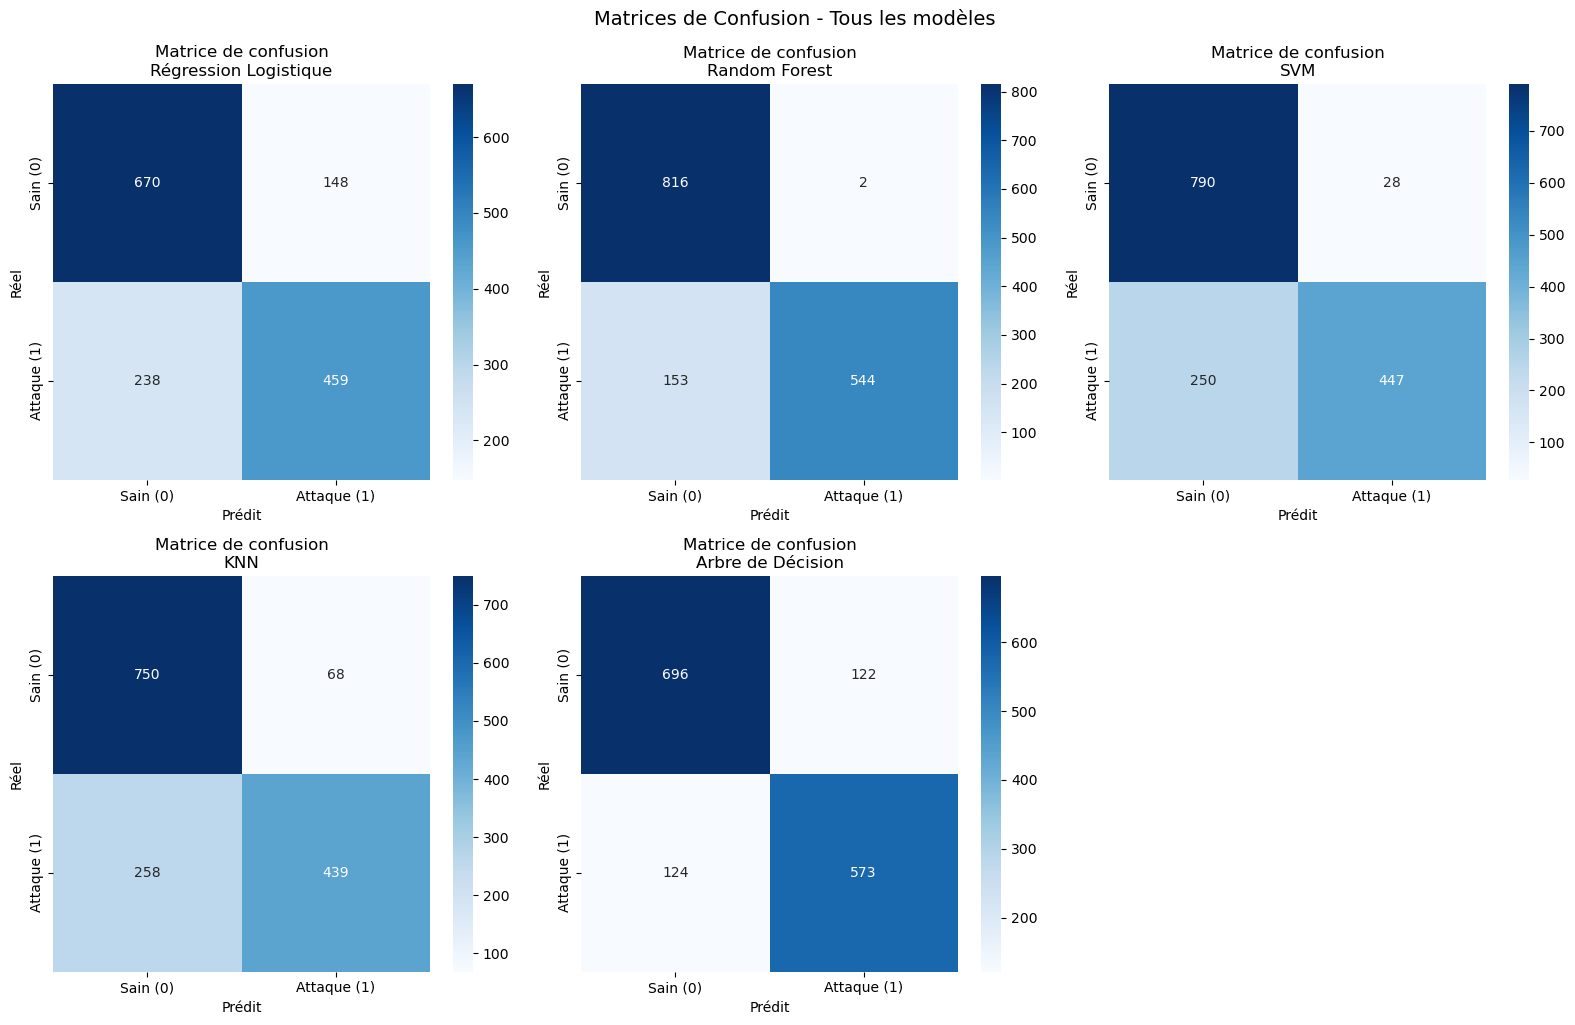

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Sain (0)', 'Attaque (1)'],
                yticklabels=['Sain (0)', 'Attaque (1)'])
    axes[i].set_title(f"Matrice de confusion\n{name}")
    axes[i].set_xlabel("Prédit")
    axes[i].set_ylabel("Réel")

# Cacher le dernier subplot vide
axes[-1].set_visible(False)
plt.tight_layout()
plt.suptitle("Matrices de Confusion - Tous les modèles", fontsize=14, y=1.02)
plt.show()

### 4.3 Courbes ROC

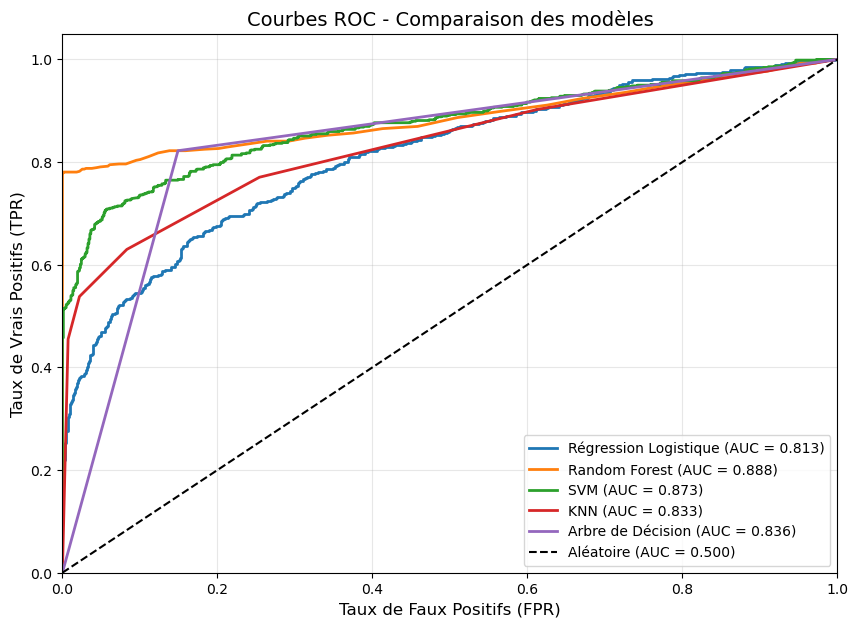

In [9]:
plt.figure(figsize=(10, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (name, model), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label="Aléatoire (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de Faux Positifs (FPR)", fontsize=12)
plt.ylabel("Taux de Vrais Positifs (TPR)", fontsize=12)
plt.title("Courbes ROC - Comparaison des modèles", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

### 4.4 Visualisation comparative des métriques

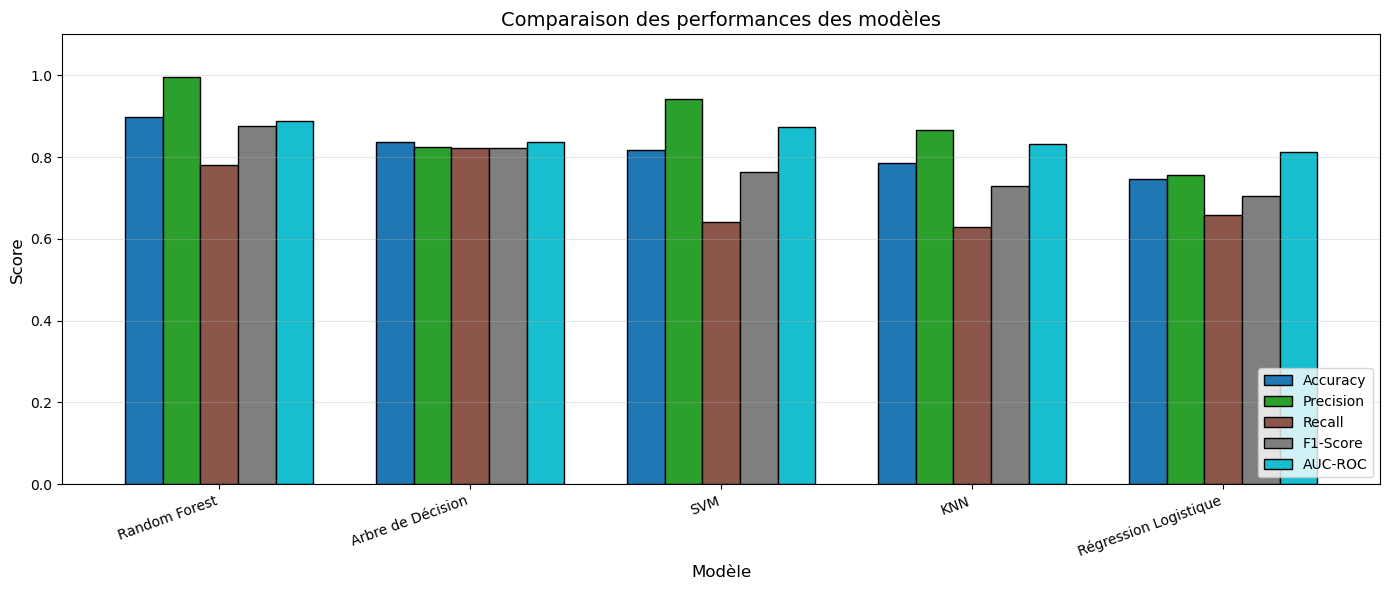

In [10]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
df_plot = df_results.set_index("Modèle")[metrics]

df_plot.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='black', width=0.75)
plt.title("Comparaison des performances des modèles", fontsize=14)
plt.xlabel("Modèle", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Importance des features (Random Forest)

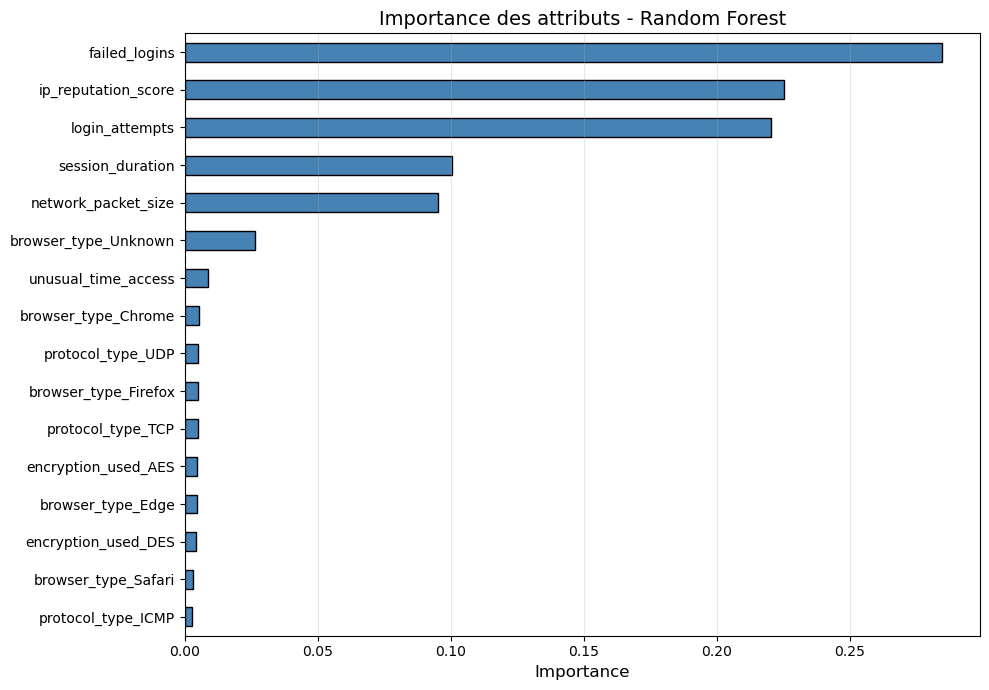


Top 5 attributs les plus importants :
failed_logins          0.284761
ip_reputation_score    0.225267
login_attempts         0.220523
session_duration       0.100243
network_packet_size    0.095163
dtype: float64


In [11]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Importance des attributs - Random Forest", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 attributs les plus importants :")
print(importances.sort_values(ascending=False).head())

### 4.6 Rapport de classification du meilleur modèle

In [12]:
best_model_name = df_results.iloc[0]["Modèle"]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"=== Meilleur modèle : {best_model_name} ===")
print()
print(classification_report(y_test, y_pred_best, target_names=["Sain (0)", "Attaque (1)"]))

=== Meilleur modèle : Random Forest ===

              precision    recall  f1-score   support

    Sain (0)       0.84      1.00      0.91       818
 Attaque (1)       1.00      0.78      0.88       697

    accuracy                           0.90      1515
   macro avg       0.92      0.89      0.89      1515
weighted avg       0.91      0.90      0.90      1515



In [13]:
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib.dump(
    trained_models["Random Forest"],
    model_dir / "random_forest_model.joblib"
)

print("✅ Modèle Random Forest enregistré avec succès.")

✅ Modèle Random Forest enregistré avec succès.
